# 2.0 — Baseline Training: YOLOv8s (Raw, No Imbalance Handling)

Train a unified YOLOv8s model on the raw Construction Site Safety dataset **without any class imbalance handling**. This establishes the baseline performance.

**Architecture note:** All training logic lives in `algear.modeling.train`; this notebook orchestrates and visualises results.

## Setup

In [5]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib

In [6]:
# @title Mount Google Drive (or clone the repo)
import os
from pathlib import Path
import sys

# Option A: Mount Drive and point to your project folder
# from google.colab import drive
# drive.mount('/content/drive')

# Update this path to match where you placed the AlGear project
# PROJECT_DIR = Path("/content/drive/MyDrive/AlGear")

# Option B: Uncomment to clone from GitHub instead
!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")
print(f"Contents: {list(PROJECT_DIR.iterdir())[:10]}")

Cloning into 'AlGear'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 64 (delta 20), reused 61 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 22.14 MiB | 17.69 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Project root: /content/AlGear
Contents: [PosixPath('/content/AlGear/setup.cfg'), PosixPath('/content/AlGear/algear'), PosixPath('/content/AlGear/data'), PosixPath('/content/AlGear/Makefile'), PosixPath('/content/AlGear/notebooks'), PosixPath('/content/AlGear/.git'), PosixPath('/content/AlGear/yolo26n.pt'), PosixPath('/content/AlGear/.gitignore'), PosixPath('/content/AlGear/runs'), PosixPath('/content/AlGear/yolov8s.pt')]


In [ ]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""  # <-- Paste your key here

# Verify
from algear.config import ROBOFLOW_API_KEY, ROBOFLOW_DIR, ROBOFLOW_WORKSPACE, ROBOFLOW_PROJECT, ROBOFLOW_VERSION
print(f"Workspace: {ROBOFLOW_WORKSPACE}, Project: {ROBOFLOW_PROJECT}, v{ROBOFLOW_VERSION}")
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")

Workspace: roboflow-100, Project: construction-safety-gsnvb, v1
API key set: True


In [ ]:
# @title Download dataset from Roboflow (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-22 11:26:51.677 | INFO     | algear.dataset:download_roboflow:33 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 6318.83it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-22 11:27:20.781 | SUCCESS  | algear.dataset:download_roboflow:37 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Class Distribution

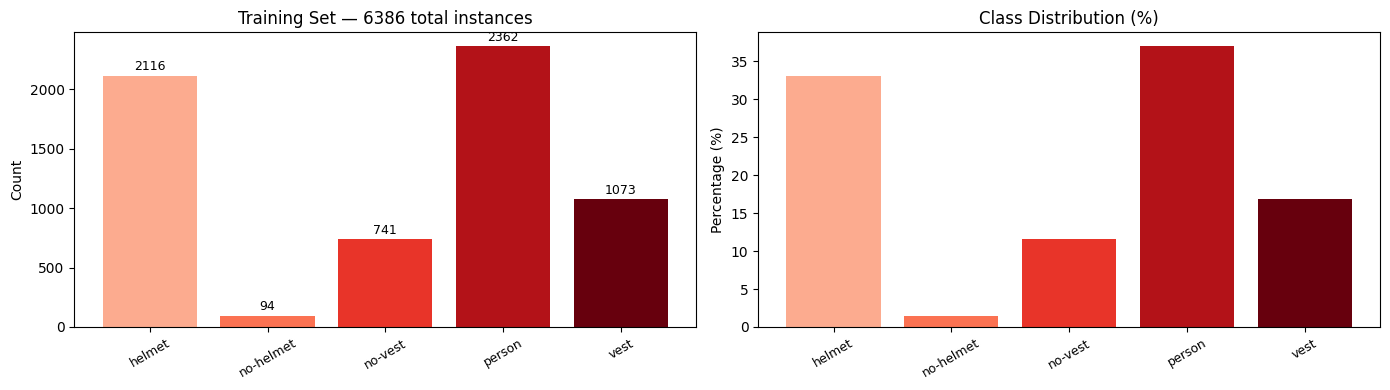

Imbalance ratio (helmet:no-helmet):  22.5x
Imbalance ratio (vest:no-vest):      1.4x


In [8]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import yaml

from algear.config import ROBOFLOW_DIR

with open(ROBOFLOW_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]

def count_classes(split: str) -> Counter:
    c = Counter()
    for lbl in sorted((ROBOFLOW_DIR / split / "labels").glob("*.txt")):
        with open(lbl) as f:
            for line in f:
                c[int(line.strip().split()[0])] += 1
    return c

train_counts = count_classes("train")
total = sum(train_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
names = [class_names[i] for i in range(len(class_names))]
counts = [train_counts.get(i, 0) for i in range(len(class_names))]
colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(names)))

ax1.bar(names, counts, color=colors)
ax1.set_title(f"Training Set — {total} total instances")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30, labelsize=9)
for bar, c in zip(ax1.containers[0], counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(c), ha="center", va="bottom", fontsize=9)

pcts = [c / total * 100 for c in counts]
ax2.bar(names, pcts, color=colors)
ax2.set_title("Class Distribution (%)")
ax2.set_ylabel("Percentage (%)")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {counts[0] / max(counts[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {counts[4] / max(counts[2], 1):.1f}x")

## 2. Train YOLOv8s Baseline

Using `yolov8s.pt` pretrained checkpoint, 50 epochs, **no class weights** — raw imbalanced training.

In [10]:
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: 0
GPU: Tesla T4


In [ ]:
from algear.modeling.train import train_yolov8

results = train_yolov8(
    data_yaml=ROBOFLOW_DIR / "data.yaml",
    model_name="yolov8s.pt",
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    output_dir=PROJECT_DIR / "models",
)

2026-06-22 11:28:10.161 | INFO     | algear.modeling.train:train_yolov8:28 - Training YOLOv8s on /content/AlGear/data/raw/construction-safety-gsnvb/data.yaml
2026-06-22 11:28:10.161 | INFO     | algear.modeling.train:train_yolov8:29 - Epochs=50, imgsz=640, batch=16, device=0
2026-06-22 11:28:10.161 | INFO     | algear.modeling.train:train_yolov8:30 - NOTE: No class imbalance handling — this is a raw baseline.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AlGear/data/raw/construction-safety-gsnvb/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist

## 3. Evaluate on Test Set

In [11]:
from algear.modeling.train import evaluate

metrics = evaluate(
    model_path=PROJECT_DIR / "models" / "baseline" / "weights" / "best.pt",
    data_yaml=ROBOFLOW_DIR / "data.yaml",
    split="test",
    device=device,
)

2026-06-22 12:01:08.347 | INFO     | algear.modeling.train:evaluate:72 - Evaluating /content/AlGear/models/baseline/weights/best.pt on test split
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1634.3±568.7 MB/s, size: 51.8 KB)
val: Scanning /content/AlGear/data/raw/construction-safety-gsnvb/test/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 11.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.7s
                   all         90        623      0.763      0.808      0.778      0.403
                helmet         82        195      0.825      0.933      0.929      0.512
             no-helmet         11         24      0.796      0.652      0.592      0.192
               no-vest         31         61      0

In [ ]:
from google.colab import files
files.download(str(PROJECT_DIR / "models" / "baseline" / "weights" / "best.pt"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Baseline Results

| Metric | Value | Target |
|---|---|---|
| mAP@50 (overall) | 77.8% | ≥ 80% |
| mAP@50 (no-helmet)  | 59.2% | ≥ 80% |
| mAP@50 (no-vest)    | 63% | ≥ 80% |
| Recall (no-helmet)  | 65.2% | ≥ 80% |
| Recall (no-vest)    | 70.5% | ≥ 80% |
| Precision (overall) | 76.3% | ≥ 80% |


- Overall performance (~78% mAP) is **near acceptable threshold**, meaning the model already learns general PPE detection well.
- The model is biased toward detecting **safe PPE conditions**.
- It is less sensitive to **missing PPE cases**, likely due to:
  - class imbalance
  - small object size
  - limited violation samples
